In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, Dense, Dropout


ticker = 'AAPL'
data = yf.download(ticker, start='2016-01-01', end='2026-01-01')['Close']
data = data.dropna()

/tmp/ipykernel_7839/3340137786.py:13: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start='2016-01-01', end='2026-01-01')['Close']
[*********************100%***********************]  1 of 1 completed


/tmp/ipykernel_7839/3191851108.py:10: FutureWarning: YF.download() has changed argument auto_adjust default to True
  eda_data = yf.download('AAPL', start='2016-01-01', end='2026-01-01')
[*********************100%***********************]  1 of 1 completed

Generating Exploratory Data Visualization...


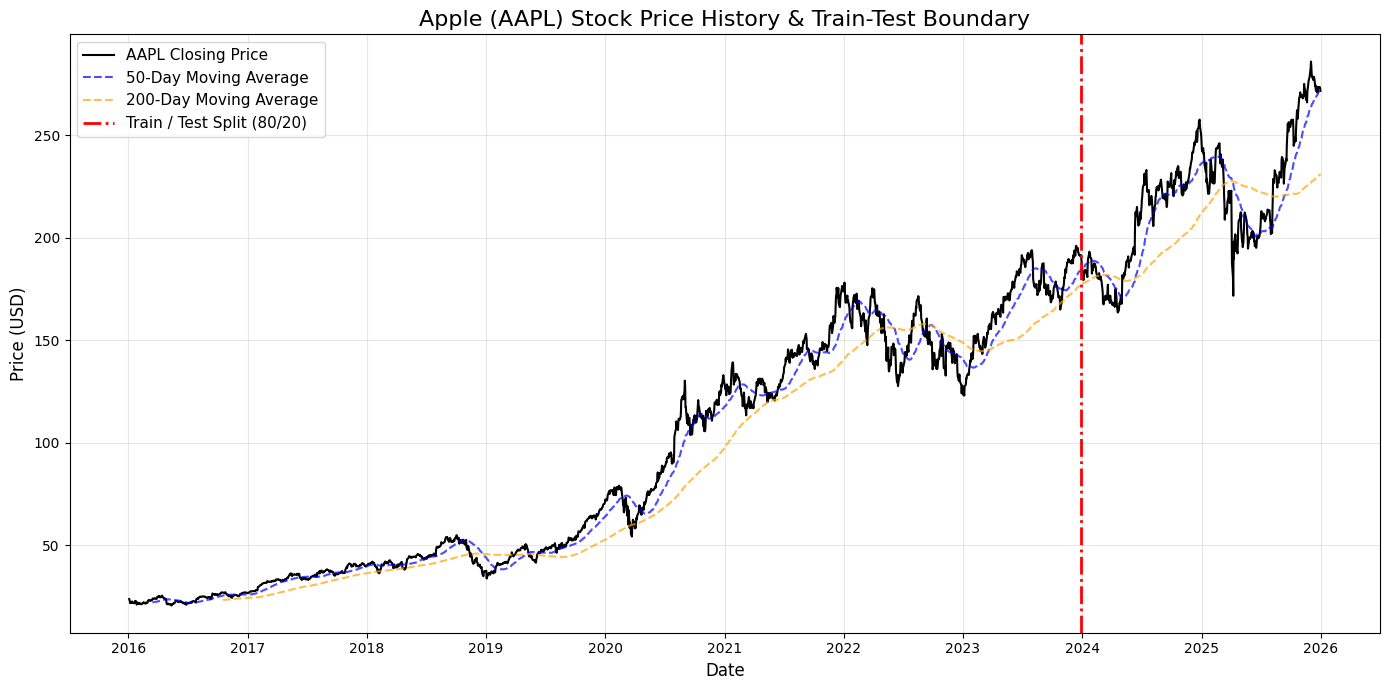

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# ==========================================
# Exploratory Data Analysis (EDA) Plot
# ==========================================
print("Generating Exploratory Data Visualization...")

# Calculate Moving Averages for the chart
eda_data = yf.download('AAPL', start='2016-01-01', end='2026-01-01')
eda_data['MA50'] = eda_data['Close'].rolling(window=50).mean()
eda_data['MA200'] = eda_data['Close'].rolling(window=200).mean()

# Calculate where the 80% split happens in time
split_index = int(len(eda_data) * 0.8)
split_date = eda_data.index[split_index]

# Create the plot
plt.figure(figsize=(14, 7))

# Plot the actual closing price
plt.plot(eda_data.index, eda_data['Close'], label='AAPL Closing Price', color='black', linewidth=1.5)

# Plot the Moving Averages
plt.plot(eda_data.index, eda_data['MA50'], label='50-Day Moving Average', color='blue', linestyle='--', alpha=0.7)
plt.plot(eda_data.index, eda_data['MA200'], label='200-Day Moving Average', color='orange', linestyle='--', alpha=0.7)

# Add a vertical line to show the Train/Test Split
plt.axvline(x=split_date, color='red', linestyle='-.', linewidth=2, label='Train / Test Split (80/20)')

# Formatting the graph to look professional
plt.title('Apple (AAPL) Stock Price History & Train-Test Boundary', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Price (USD)', fontsize=12)
plt.legend(loc='upper left', fontsize=11)
plt.grid(True, alpha=0.3)

# Show the plot
plt.tight_layout()
plt.show()

In [ ]:
# Scale data
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data.values.reshape(-1, 1))

# Create sequences (window=60 days to predict next day)
def create_sequences(data, window=60):
    X, y = [], []
    for i in range(window, len(data)):
        X.append(data[i-window:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

window = 60
X, y = create_sequences(scaled_data, window)
X = X.reshape((X.shape[0], X.shape[1], 1))  # For Keras: (samples, timesteps, features)

# Train-test split (80/20, time-ordered)
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

In [ ]:

model = Sequential([
    # A single, standard LSTM layer
    LSTM(50, input_shape=(window, 1)),

    # A standard dropout layer to prevent overfitting
    Dropout(0.2),

    # The final output node predicting the single next price
    Dense(1)
])

model.compile(optimizer='adam', loss='mse')
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 50)             │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,451 (40.82 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 4s 30ms/step - loss: 0.0148 - val_loss: 0.0017
Epoch 2/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - loss: 0.0016 - val_loss: 0.0010
Epoch 3/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - loss: 0.0013 - val_loss: 8.4537e-04
Epoch 4/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - loss: 0.0012 - val_loss: 0.0014
Epoch 5/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - loss: 9.7099e-04 - val_loss: 8.5032e-04
Epoch 6/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - loss: 9.4296e-04 - val_loss: 8.2139e-04
Epoch 7/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - loss: 8.7541e-04 - val_loss: 0.0016
Epoch 8/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - loss: 9.1555e-04 - val_loss: 0.0023
Epoch 9/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - loss: 9.0533e-04 - val_loss: 0.0016
Epoch 10/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - loss: 8.6938e-04 - val_loss: 0.0012
Epoch 11/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - loss: 9.0883e-04 - val_loss: 7.6976e-04
Epoch 12/30
62/62 ━

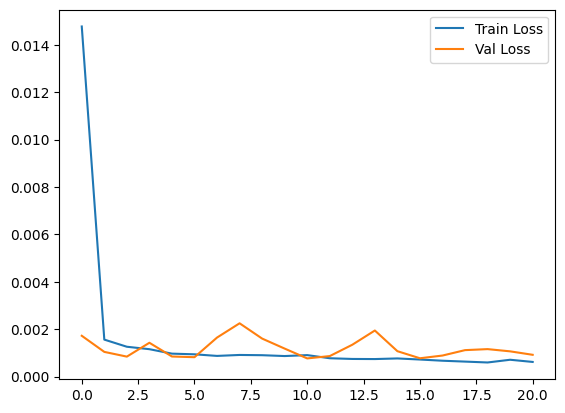

In [ ]:
history = model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[tf.keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True)]
)

# Plot training loss
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.show()


Generating Training Loss Curve...


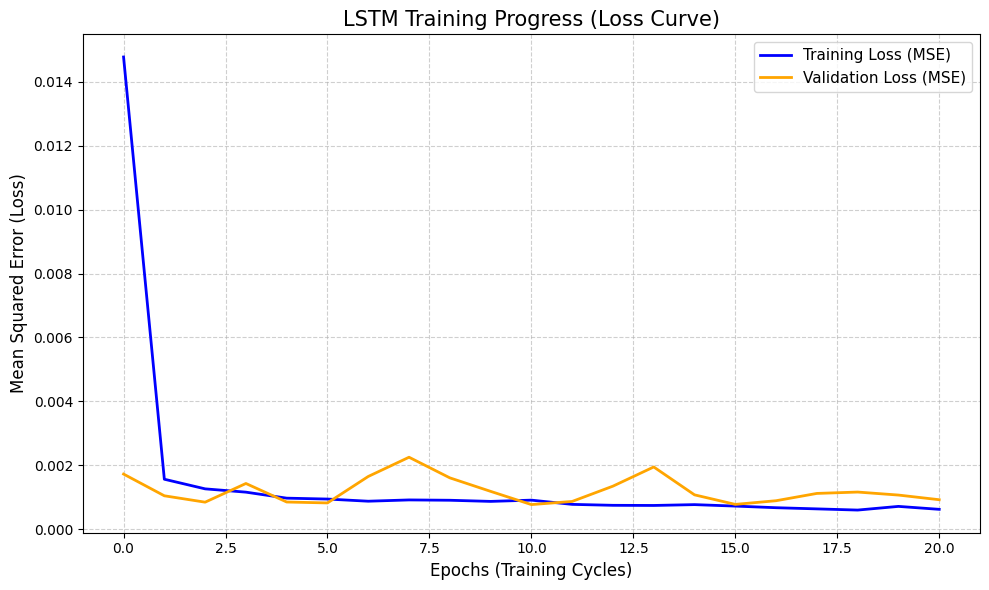

In [ ]:
import matplotlib.pyplot as plt

# ==========================================
# Training History Plot (Loss Curve)
# ==========================================
print("Generating Training Loss Curve...")

plt.figure(figsize=(10, 6))

# Plot the training and validation loss from the 'history' object
plt.plot(history.history['loss'], label='Training Loss (MSE)', color='blue', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation Loss (MSE)', color='orange', linewidth=2)

# Formatting the graph
plt.title('LSTM Training Progress (Loss Curve)', fontsize=15)
plt.xlabel('Epochs (Training Cycles)', fontsize=12)
plt.ylabel('Mean Squared Error (Loss)', fontsize=12)
plt.legend(loc='upper right', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
Test RMSE: 7.36


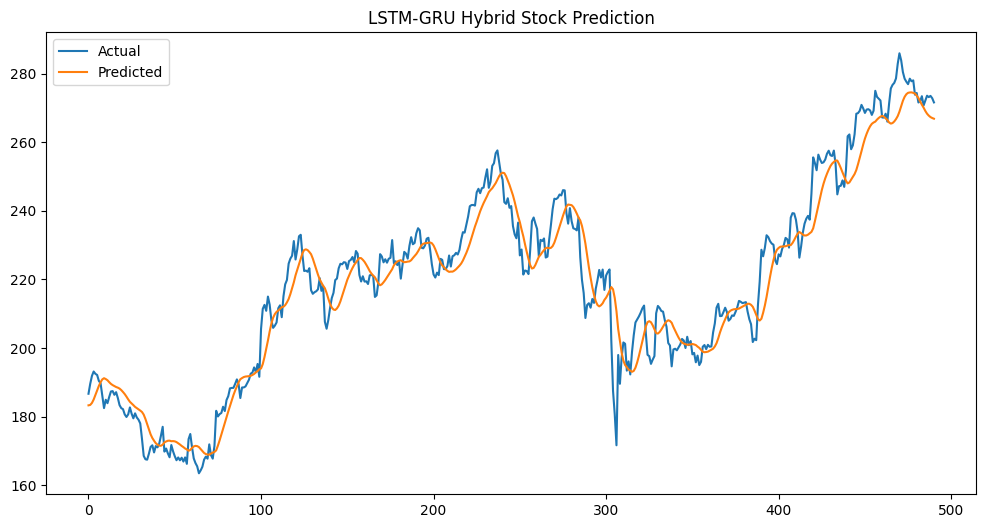

In [ ]:
# Predict on test set
y_pred = model.predict(X_test)
y_pred = scaler.inverse_transform(y_pred)
y_test_inv = scaler.inverse_transform(y_test.reshape(-1, 1))

# Metrics
rmse = np.sqrt(mean_squared_error(y_test_inv, y_pred))
print(f'Test RMSE: {rmse:.2f}')

# Plot predictions
plt.figure(figsize=(12, 6))
plt.plot(y_test_inv, label='Actual')
plt.plot(y_pred, label='Predicted')
plt.legend()
plt.title('LSTM-GRU Hybrid Stock Prediction')
plt.show()


Generating predictions...
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
Test RMSE: $7.36


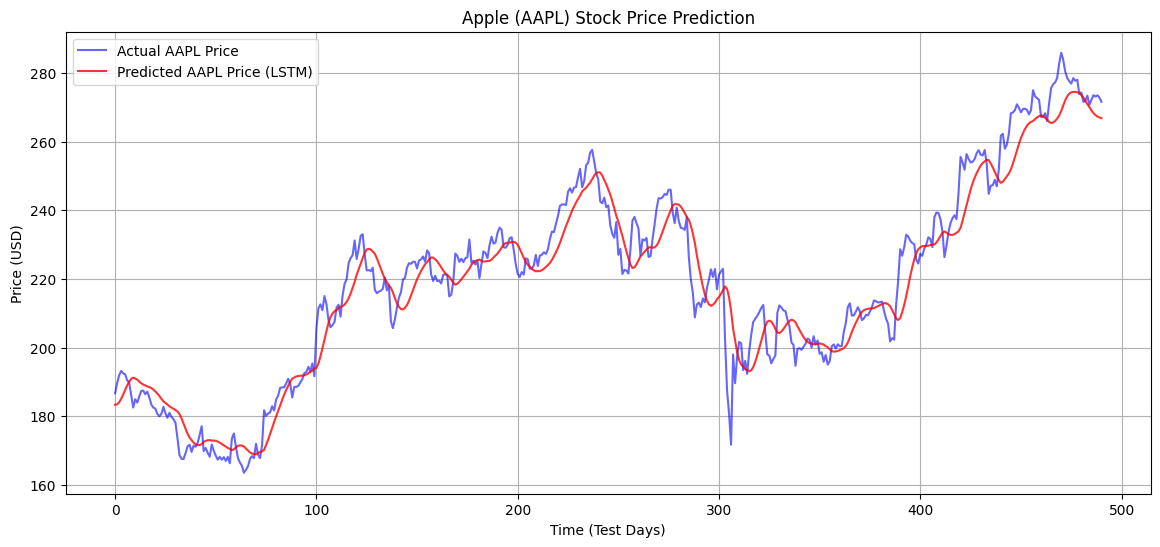

In [ ]:
# ==========================================
# Final Steps: Predict, Unscale, and Plot
# ==========================================

# 1. Generate predictions on the test data
print("Generating predictions...")
predictions = model.predict(X_test)

# 2. Inverse transform the numbers back to real stock prices
predictions_unscaled = scaler.inverse_transform(predictions)
y_test_unscaled = scaler.inverse_transform(y_test.reshape(-1, 1))

# 3. Calculate a basic error metric (Root Mean Squared Error)
rmse = np.sqrt(mean_squared_error(y_test_unscaled, predictions_unscaled))
print(f'Test RMSE: ${rmse:.2f}')

# 4. Plot the Actual vs. Predicted prices
plt.figure(figsize=(14, 6))
plt.plot(y_test_unscaled, color='blue', label='Actual AAPL Price', alpha=0.6)
plt.plot(predictions_unscaled, color='red', label='Predicted AAPL Price (LSTM)', alpha=0.8)
plt.title('Apple (AAPL) Stock Price Prediction')
plt.xlabel('Time (Test Days)')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True)
plt.show()

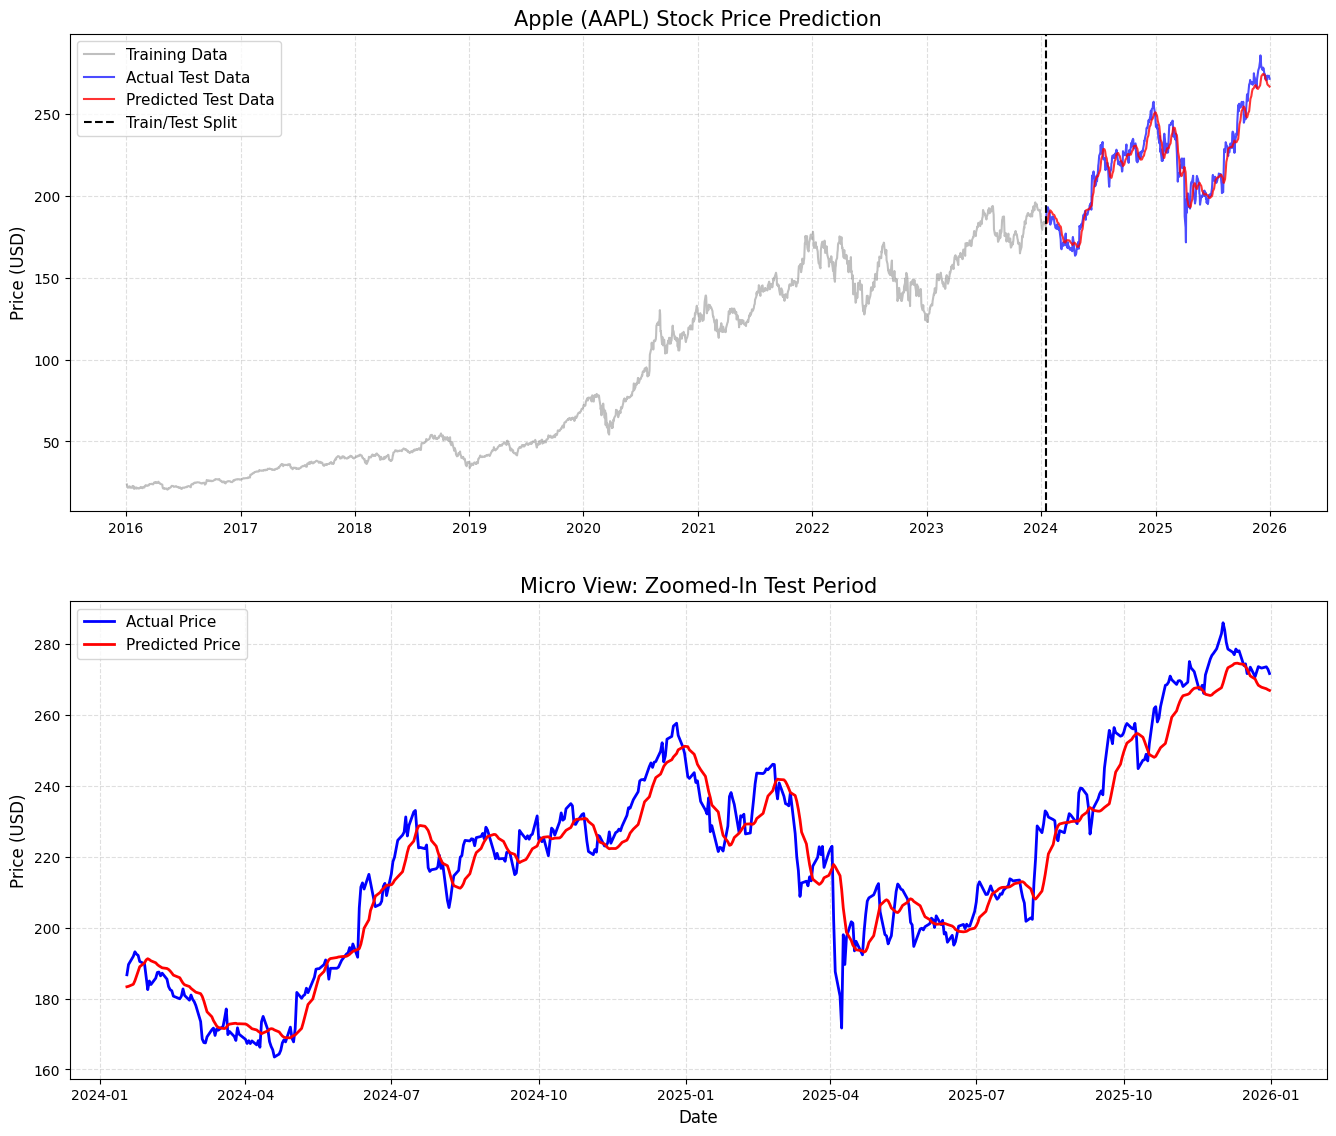

In [ ]:
import matplotlib.pyplot as plt

# ==========================================
# Advanced Visualization: Macro & Micro Views
# ==========================================

# 1. Align the dates
# Since the predictions align with the very end of your dataset,
# we grab the last len(y_pred) dates for the test set, and the rest for training.
test_dates = data.index[-len(y_pred):]
train_dates = data.index[:-len(y_pred)]

train_actual = data.values[:-len(y_pred)]
test_actual = data.values[-len(y_pred):]

# 2. Create the figure and subplots (2 rows, 1 column)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 12))

# --- TOP PLOT: Macro View (Entire Dataset) ---
ax1.plot(train_dates, train_actual, label='Training Data', color='gray', alpha=0.5)
ax1.plot(test_dates, test_actual, label='Actual Test Data', color='blue', alpha=0.7)
ax1.plot(test_dates, y_pred, label='Predicted Test Data', color='red', alpha=0.8)

# Add a vertical line exactly where the training stops and testing begins
ax1.axvline(x=test_dates[0], color='black', linestyle='--', linewidth=1.5, label='Train/Test Split')

ax1.set_title('Apple (AAPL) Stock Price Prediction', fontsize=15)
ax1.set_ylabel('Price (USD)', fontsize=12)
ax1.legend(loc='upper left', fontsize=11)
ax1.grid(True, linestyle='--', alpha=0.4)

# --- BOTTOM PLOT: Micro View (Zoomed In on Predictions) ---
ax2.plot(test_dates, y_test_inv, label='Actual Price', color='blue', linewidth=2)
ax2.plot(test_dates, y_pred, label='Predicted Price', color='red', linewidth=2)

ax2.set_title('Micro View: Zoomed-In Test Period', fontsize=15)
ax2.set_xlabel('Date', fontsize=12)
ax2.set_ylabel('Price (USD)', fontsize=12)
ax2.legend(loc='upper left', fontsize=11)
ax2.grid(True, linestyle='--', alpha=0.4)

# Adjust layout so they don't overlap and display the graph
plt.tight_layout(pad=3.0)
plt.show()